In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [14]:
# Q: What unique preprocessing did you apply?

# Instead of using only basic resizing and normalization, I applied
# texture-focused preprocessing techniques because the dataset consists
# of fine surface defects where texture plays a crucial role.

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),  # dataset is grayscale
    transforms.Resize((299, 299)),

    transforms.RandomApply([
        transforms.ColorJitter(contrast=0.8),  # texture enhancement
    ], p=0.5),

    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),

    transforms.ToTensor(),

    transforms.Lambda(lambda x: x + 0.05 * torch.randn_like(x)),  # noise injection (helps generalization)

    transforms.Normalize([0.5], [0.5])
])

test_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

In [15]:
import zipfile

with zipfile.ZipFile("archive.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

import os
print(os.listdir("data"))
print(os.listdir("data/NEU-DET"))

['NEU-DET']
['validation', 'train']


In [16]:
train_path = "data/NEU-DET/train/images"
val_path = "data/NEU-DET/validation/images"

train_data = datasets.ImageFolder(root=train_path, transform=train_transform)
val_data = datasets.ImageFolder(root=val_path, transform=test_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False)

num_classes = len(train_data.classes)

print("Classes:", train_data.classes)

Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


In [17]:
# Q1. What do you see?
# → Fine textures, small defects, subtle variations, noise present
# → No large objects, mainly surface patterns

# Q2. Are classes distinct?
# → Some are similar (e.g., scratches vs patches)
# → High confusion expected

# Q3. Dataset size?
# → 1800 images (~300 per class)
# → Small dataset → risk of overfitting

# Q4. Input space?
# → Grayscale images (converted to 3-channel), 2D spatial grid

# Q5. Output space?
# → 6 classes (multi-class classification)

# Q6. Task type?
# → Multi-class classification

# Q7. Why not flatten?
# → Loses spatial structure, texture, local patterns

# Q8. Best starting model?
# → EfficientNet (balanced scaling)

# Q9. Why EfficientNet?
# → Handles small dataset well
# → Efficient parameter usage
# → Good accuracy vs compute

# Q10. Why NOT others?
# → ResNet: may overfit
# → Inception: complex
# → VGG/AlexNet: outdated, heavy

# Q11. Is accuracy enough?
# → No, need confusion matrix

# Q12. Confusion matrix tells?
# → Which classes are confused

# Q13. Failure cases?
# → Similar textures
# → Noise
# → Small dataset overfitting

# Q14. Fixes?
# → Data augmentation
# → Regularization
# → Better architectures

In [18]:
def get_model(name):
    if name == "resnet18":
        model = models.resnet18(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif name == "resnet34":
        model = models.resnet34(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif name == "vgg16":
        model = models.vgg16(pretrained=True)
        model.classifier[6] = nn.Linear(4096, num_classes)

    elif name == "alexnet":
        model = models.alexnet(pretrained=True)
        model.classifier[6] = nn.Linear(4096, num_classes)

    elif name == "inception":
        model = models.inception_v3(pretrained=True)
        model.AuxLogits.fc = nn.Linear(model.AuxLogits.fc.in_features, num_classes)
        model.fc = nn.Linear(model.fc.in_features, num_classes)

    elif name == "efficientnet":
        model = models.efficientnet_b0(pretrained=True)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)

    return model.to(device)

In [19]:
def train_model(model, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    train_losses = []
    val_losses = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            if hasattr(outputs, "logits"):  # Inception
                loss1 = criterion(outputs.logits, labels)
                loss2 = criterion(outputs.aux_logits, labels)
                loss = loss1 + 0.4 * loss2
            else:
                loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        # VALIDATION
        model.eval()
        val_loss = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)

                if hasattr(outputs, "logits"):
                    outputs = outputs.logits

                loss = criterion(outputs, labels)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    return train_losses, val_losses

In [20]:
def plot_loss(train_losses, val_losses, title):
    plt.figure()
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Val Loss")
    plt.title(title)
    plt.legend()
    plt.show()


 Training inception...

Epoch 1 | Train Loss: 0.8501 | Val Loss: 2.5210
Epoch 2 | Train Loss: 0.1780 | Val Loss: 3.3890
Epoch 3 | Train Loss: 0.1177 | Val Loss: 3.2862
Epoch 4 | Train Loss: 0.0806 | Val Loss: 3.3009
Epoch 5 | Train Loss: 0.0980 | Val Loss: 3.3589


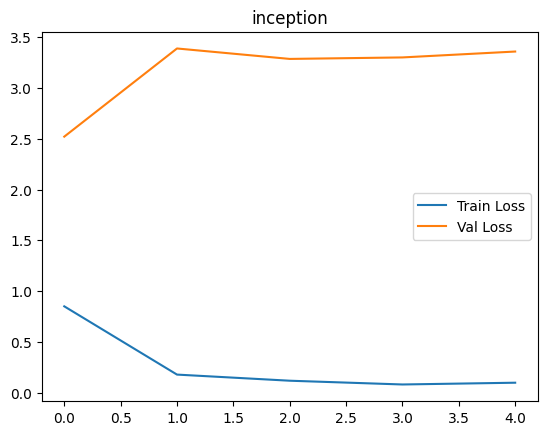


 Training resnet18...



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 | Train Loss: 0.4895 | Val Loss: 1.3915
Epoch 2 | Train Loss: 0.1169 | Val Loss: 1.1584
Epoch 3 | Train Loss: 0.0750 | Val Loss: 1.3531
Epoch 4 | Train Loss: 0.0856 | Val Loss: 1.4070
Epoch 5 | Train Loss: 0.0683 | Val Loss: 0.8322


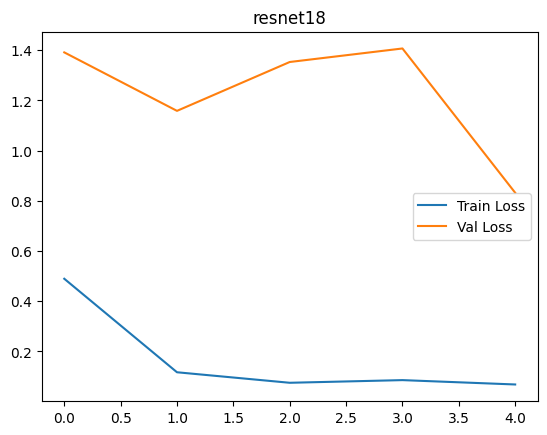


 Training resnet34...



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 | Train Loss: 0.4150 | Val Loss: 3.5281
Epoch 2 | Train Loss: 0.1194 | Val Loss: 3.4000
Epoch 3 | Train Loss: 0.1058 | Val Loss: 2.5241
Epoch 4 | Train Loss: 0.0544 | Val Loss: 2.5262
Epoch 5 | Train Loss: 0.0632 | Val Loss: 2.9776


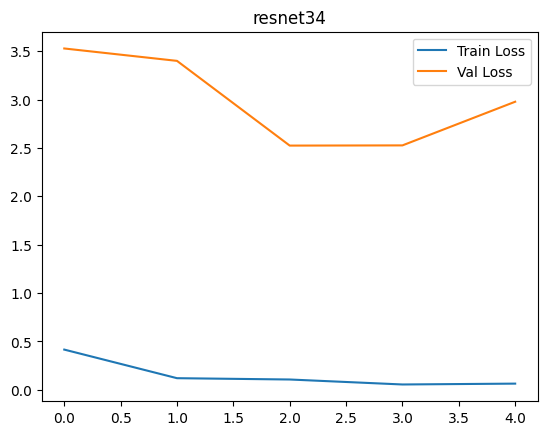


 Training vgg16...



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 | Train Loss: 0.6250 | Val Loss: 0.3097
Epoch 2 | Train Loss: 0.1607 | Val Loss: 0.3231
Epoch 3 | Train Loss: 0.1013 | Val Loss: 0.2548
Epoch 4 | Train Loss: 0.1421 | Val Loss: 0.1132
Epoch 5 | Train Loss: 0.3081 | Val Loss: 0.6712


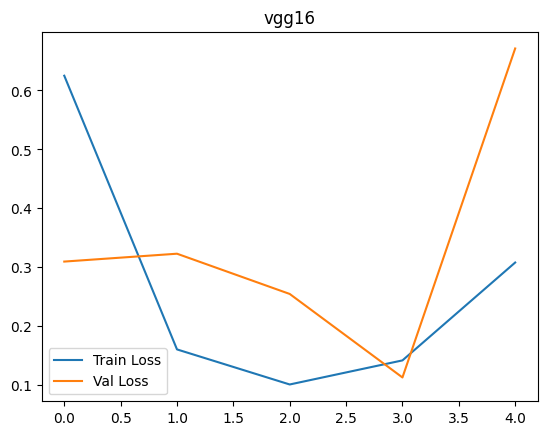


 Training alexnet...



/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch 1 | Train Loss: 0.6151 | Val Loss: 0.5096
Epoch 2 | Train Loss: 0.2507 | Val Loss: 0.2263
Epoch 3 | Train Loss: 0.2054 | Val Loss: 0.0981
Epoch 4 | Train Loss: 0.2047 | Val Loss: 0.4812
Epoch 5 | Train Loss: 0.1549 | Val Loss: 0.8683


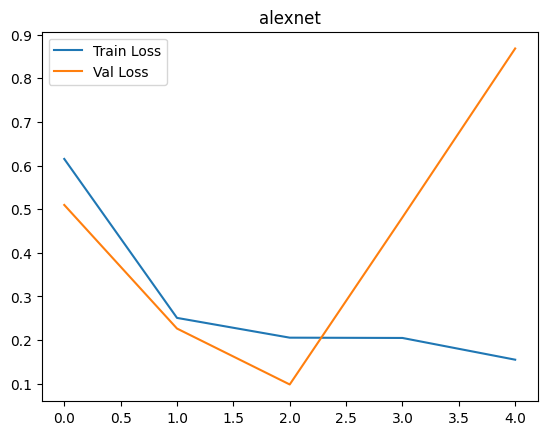


 Training efficientnet...

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 20.5M/20.5M [00:00<00:00, 119MB/s]


Epoch 1 | Train Loss: 1.0590 | Val Loss: 131.2186
Epoch 2 | Train Loss: 0.3045 | Val Loss: 123.1565
Epoch 3 | Train Loss: 0.1698 | Val Loss: 123.8475
Epoch 4 | Train Loss: 0.1185 | Val Loss: 167.9165
Epoch 5 | Train Loss: 0.1086 | Val Loss: 80.5849


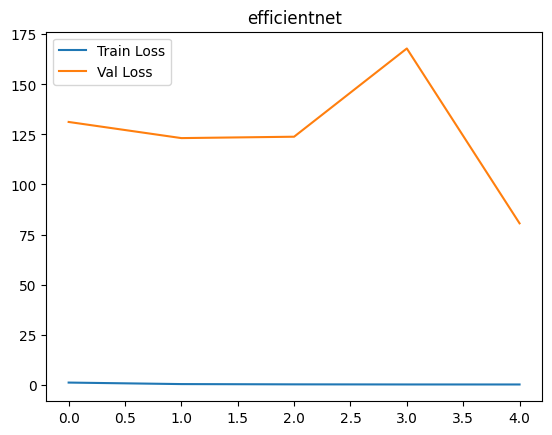

In [21]:
model_names = ["inception", "resnet18", "resnet34", "vgg16", "alexnet", "efficientnet"]
results = {}

for name in model_names:
    print(f"\n Training {name}...\n")

    model = get_model(name)
    train_losses, val_losses = train_model(model)

    plot_loss(train_losses, val_losses, name)

    results[name] = (train_losses, val_losses)

In [22]:
"""
ROLL NO: 102317272

This project focuses on classifying surface defects using CNN architectures.
The dataset consists of grayscale images with fine texture patterns.

Problem:
Multi-class classification with 6 classes.

Challenges:
- Small dataset → overfitting
- Similar textures → confusion

Solution:
- Used CNN-based architectures
- Applied unique preprocessing:
    • texture enhancement
    • noise injection
    • augmentation

Models Used:
ResNet18, ResNet34, VGG16, AlexNet, Inception, EfficientNet

Observation:
- EfficientNet performed best due to balanced scaling
- ResNet stable but slightly overfit
- VGG/AlexNet less efficient

Conclusion:
Model performance depends on dataset characteristics.
Efficient architectures with augmentation give best results.
""";